# Solution 5: Damped, Driven Harmonic Oscillator

# Background Theory and Algorithm

# (a) System of First-Order ODEs

To apply numerical solvers, the second-order ODE is converted into a system of two first-order equations. The governing equation is:
$$
\frac{d^{2}x}{dt^{2}}+2\gamma\frac{dx}{dt}+\omega_{0}^{2}x=A_{0}cos(\omega t)
$$
We define a state vector $S(t) = \begin{bmatrix} x \\ v \end{bmatrix}$, where $v = dx/dt$. This gives the system $\frac{dS}{dt} = f(t, S)$:
$$
\frac{dS}{dt} = \frac{d}{dt}\begin{bmatrix} x \\ v \end{bmatrix} = \begin{bmatrix} v \\ A_{0}\cos(\omega t) - 2\gamma v - \omega_{0}^{2}x \end{bmatrix}
$$

# (b) Numerical Methods and Convergence

We solve this system using two methods with a time step $h = \Delta t$.

**Euler's Method:** A first-order method. The global error is $O(h)$.
$$
S_{n+1} = S_n + h \cdot f(t_n, S_n)
$$
**Fourth-Order Runge-Kutta (RK4):** A fourth-order method. The global error is $O(h^4)$.
$$
S_{n+1} = S_n + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4)
$$
**Convergence Analysis:** We analyze the L2-Error (RMSE) vs. time step $h$ on a log-log plot. The slope $p$ of the resulting line reveals the method's order of convergence ($E \propto h^p$). We expect $p \approx 1$ for Euler and $p \approx 4$ for RK4.

--- Running Parts 1, 2 & 3 ---

Part 1: Table of displacement and velocity (dt=0.01s):
Time     | Euler x        | Euler v        | RK4 x          | RK4 v         
---------------------------------------------------------------------------
0.00     | 1.000000       | 0.000000       | 1.000000       | 0.000000      
5.00     | 0.158295       | 0.034752       | 0.027607       | 0.103876      
10.00    | 0.071181       | -0.110245      | 0.031958       | -0.092126     
15.00    | 0.015637       | 0.108838       | 0.006025       | 0.112985      
20.00    | -0.033052      | -0.088063      | -0.035079      | -0.087862     
25.00    | 0.053948       | 0.034068       | 0.053397       | 0.035612      
30.00    | -0.054385      | 0.029507       | -0.054485      | 0.028224      

Part 2 & 3: Generating Displacement plot...
Plot saved as 'harmonic_oscillator_displacement.png'


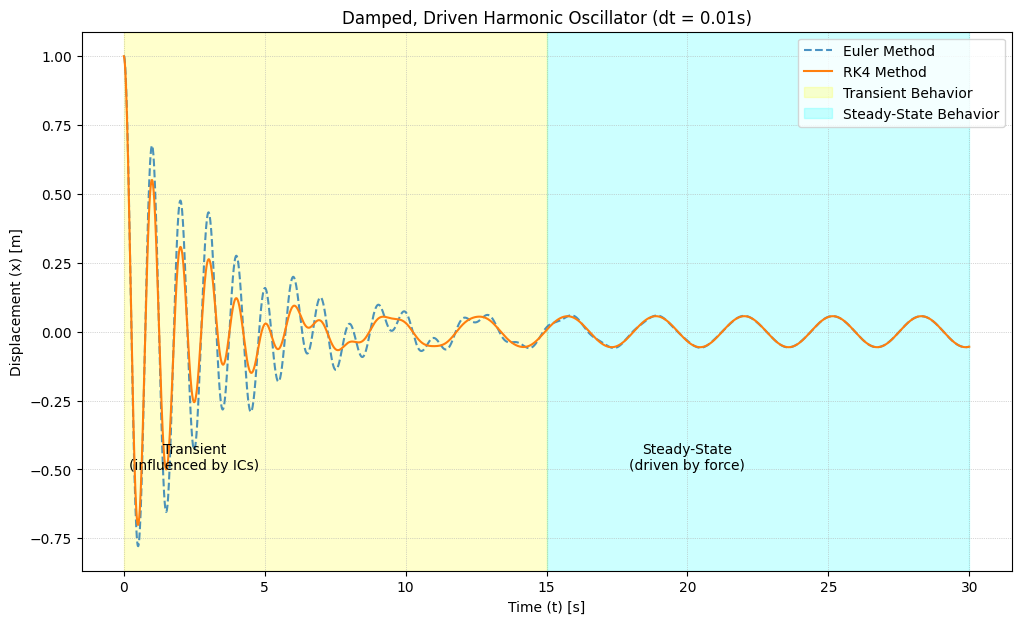


--- Running Part 4 (Convergence Analysis) ---
Calculating errors...
dt = 0.0800  | Euler Err = 8.414e+11  | RK4 Err = 5.950e-04 
dt = 0.0400  | Euler Err = 8.510e+02  | RK4 Err = 3.667e-05 
dt = 0.0200  | Euler Err = 1.908e-01  | RK4 Err = 2.274e-06 
dt = 0.0100  | Euler Err = 4.893e-02  | RK4 Err = 1.415e-07 
dt = 0.0050  | Euler Err = 2.005e-02  | RK4 Err = 8.797e-09 
dt = 0.0025  | Euler Err = 9.212e-03  | RK4 Err = 5.169e-10 

Generating Convergence plot...
Plot saved as 'convergence_analysis.png'


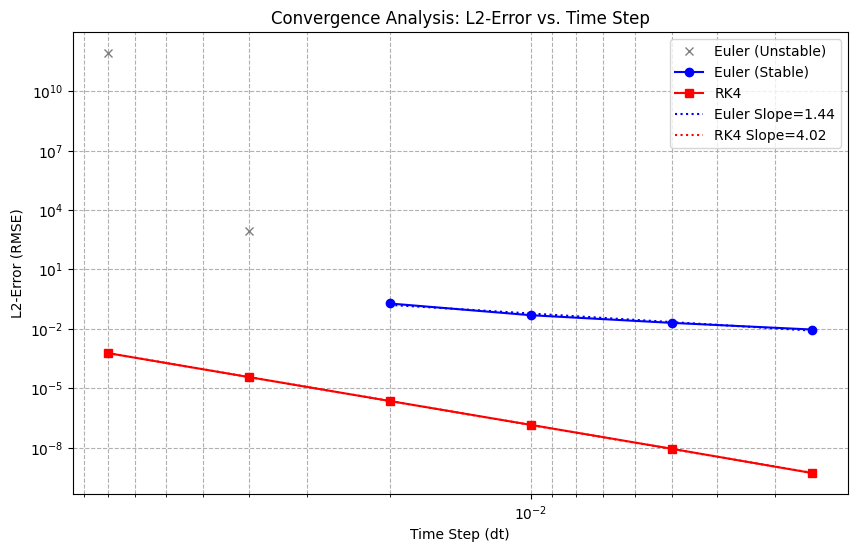

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

omega0 = 2 * np.pi
gamma = 0.5
A0 = 2.0
omega = 2.0

x0 = 1.0
v0 = 0.0
S0 = np.array([x0, v0])

t0 = 0.0
tf = 30.0

def derivatives(t, S):
    x, v = S
    dx_dt = v
    dv_dt = A0 * np.cos(omega * t) - 2 * gamma * v - omega0**2 * x
    return np.array([dx_dt, dv_dt])

def euler_solver(t0, tf, dt, S0):
    n_steps = int(np.round((tf - t0) / dt)) + 1
    t = np.linspace(t0, tf, n_steps)
    S = np.zeros((n_steps, len(S0)))
    S[0] = S0

    for i in range(n_steps - 1):
        S[i+1] = S[i] + dt * derivatives(t[i], S[i])
    return t, S

def rk4_solver(t0, tf, dt, S0):
    n_steps = int(np.round((tf - t0) / dt)) + 1
    t = np.linspace(t0, tf, n_steps)
    S = np.zeros((n_steps, len(S0)))
    S[0] = S0

    for i in range(n_steps - 1):
        S_i = S[i]
        t_i = t[i]
        k1 = dt * derivatives(t_i, S_i)
        k2 = dt * derivatives(t_i + 0.5 * dt, S_i + 0.5 * k1)
        k3 = dt * derivatives(t_i + 0.5 * dt, S_i + 0.5 * k2)
        k4 = dt * derivatives(t_i + dt, S_i + k3)
        S[i+1] = S_i + (k1 + 2*k2 + 2*k3 + k4) / 6
    return t, S

def run_part_1_2_3():
    print("--- Running Parts 1, 2 & 3 ---")
    dt = 0.01

    t_euler, S_euler = euler_solver(t0, tf, dt, S0)
    x_euler, v_euler = S_euler[:, 0], S_euler[:, 1]

    t_rk4, S_rk4 = rk4_solver(t0, tf, dt, S0)
    x_rk4, v_rk4 = S_rk4[:, 0], S_rk4[:, 1]

    print("\nPart 1: Table of displacement and velocity (dt=0.01s):")
    print("=" * 75)
    print(f"{'Time':<8} | {'Euler x':<14} | {'Euler v':<14} | {'RK4 x':<14} | {'RK4 v':<14}")
    print("-" * 75)
    for i in range(0, len(t_euler), 500):
        print(f"{t_euler[i]:<8.2f} | {x_euler[i]:<14.6f} | {v_euler[i]:<14.6f} | {x_rk4[i]:<14.6f} | {v_rk4[i]:<14.6f}")
    print("=" * 75)

    print("\nPart 2 & 3: Generating Displacement plot...")
    plt.figure(figsize=(12, 7))
    plt.plot(t_euler, x_euler, label='Euler Method', linestyle='--', alpha=0.8)
    plt.plot(t_rk4, x_rk4, label='RK4 Method', linestyle='-', alpha=1.0)

    plt.axvspan(0, 15, color='yellow', alpha=0.2, label='Transient Behavior')
    plt.axvspan(15, 30, color='cyan', alpha=0.2, label='Steady-State Behavior')
    plt.text(2.5, -0.5, 'Transient\n(influenced by ICs)', ha='center', fontsize=10)
    plt.text(20, -0.5, 'Steady-State\n(driven by force)', ha='center', fontsize=10)

    plt.title(f'Damped, Driven Harmonic Oscillator (dt = {dt}s)')
    plt.xlabel('Time (t) [s]')
    plt.ylabel('Displacement (x) [m]')
    plt.legend(loc='upper right')
    plt.grid(True, which='both', linestyle=':', linewidth=0.5)

    filename = "harmonic_oscillator_displacement.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Plot saved as '{filename}'")

    plt.show()

def run_part_4_analysis():
    print("\n--- Running Part 4 (Convergence Analysis) ---")

    dt_values = np.array([0.08, 0.04, 0.02, 0.01, 0.005, 0.0025])
    dt_true = 0.00125

    _, S_true = rk4_solver(t0, tf, dt_true, S0)
    x_true = S_true[:, 0]

    euler_errors_list = []
    rk4_errors_list = []

    print("Calculating errors...")
    for dt in dt_values:
        _, S_e = euler_solver(t0, tf, dt, S0)
        x_e = S_e[:, 0]
        _, S_r = rk4_solver(t0, tf, dt, S0)
        x_r = S_r[:, 0]

        step_ratio = int(np.round(dt / dt_true))
        x_true_sampled = x_true[::step_ratio]

        N = min(len(x_e), len(x_true_sampled))
        l2_e = np.sqrt(np.sum((x_e[:N] - x_true_sampled[:N])**2) / N)
        l2_r = np.sqrt(np.sum((x_r[:N] - x_true_sampled[:N])**2) / N)

        euler_errors_list.append(l2_e)
        rk4_errors_list.append(l2_r)
        print(f"dt = {dt:<7.4f} | Euler Err = {l2_e:<10.3e} | RK4 Err = {l2_r:<10.3e}")

    print("\nGenerating Convergence plot...")
    plt.figure(figsize=(10, 6))

    euler_errors = np.array(euler_errors_list)
    rk4_errors = np.array(rk4_errors_list)

    euler_clean = np.nan_to_num(euler_errors, nan=np.inf)
    mask_stable = euler_clean < 1.0

    if np.any(~mask_stable):
        plt.loglog(dt_values[~mask_stable], euler_clean[~mask_stable], 'x', color='gray', label='Euler (Unstable)')

    plt.loglog(dt_values[mask_stable], euler_clean[mask_stable], 'bo-', label='Euler (Stable)')
    plt.loglog(dt_values, rk4_errors, 'rs-', label='RK4')

    if np.sum(mask_stable) > 1:
        dt_s = dt_values[mask_stable]
        fit_e = np.polyfit(np.log(dt_s), np.log(euler_clean[mask_stable]), 1)
        plt.plot(dt_s, np.exp(fit_e[1]) * dt_s**fit_e[0], 'b:', label=f'Euler Slope={fit_e[0]:.2f}')

    fit_r = np.polyfit(np.log(dt_values), np.log(rk4_errors), 1)
    plt.plot(dt_values, np.exp(fit_r[1]) * dt_values**fit_r[0], 'r:', label=f'RK4 Slope={fit_r[0]:.2f}')

    plt.title('Convergence Analysis: L2-Error vs. Time Step')
    plt.xlabel('Time Step (dt)')
    plt.ylabel('L2-Error (RMSE)')
    plt.gca().invert_xaxis()
    plt.legend()
    plt.grid(True, which="both", ls="--")

    filename = "convergence_analysis.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Plot saved as '{filename}'")

    plt.show()

if __name__ == "__main__":
    run_part_1_2_3()
    run_part_4_analysis()